# Phase 1 EDA — MITRE CAR Analytics

This notebook explores the 102 CAR analytics that form the corpus for our RAG pipeline.

**Goals:**
- Understand the shape and distribution of the data
- Identify coverage gaps (analytics without implementations)
- See which tactics/platforms are well-covered vs sparse
- Understand the CAR data model fields used across analytics

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

from src.ingest import load_all_analytics

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

analytics = load_all_analytics()
df = pd.DataFrame(analytics)
print(f"Shape: {df.shape}")
df.head(3)

Loaded 102 analytics from C:\Users\kattr\thf\notebooks\..\data\raw\car\analytics
Shape: (102, 16)


,id,title,description,submission_date,information_domain,platforms,subtypes,analytic_types,techniques,subtechniques,tactics,coverage_levels,implementations,impl_types,data_model_references,raw_coverage
0,CAR-2013-01-002,Autorun Differences,The Sysinternals tool [Autoruns](../sensors/au...,2013/01/25,"Analytic, Host",[Windows],[Registry],"[Situational Awareness, TTP]","[T1037, T1053, T1112, T1543, T1546, T1547, T1574]","[T1037.001, T1053.005, T1543.003, T1546.001, T...","[TA0002, TA0003, TA0004]","[Moderate, Moderate, Moderate, Moderate, Moder...",[],[],[],"[{'technique': 'T1543', 'tactics': ['TA0003'],..."
1,CAR-2013-01-003,SMB Events Monitoring,[Server Message Block](https://en.wikipedia.or...,2013/01/25,Network,[N/A],[PCAP],[Situational Awareness],"[T1021, T1039]",[T1021.002],"[TA0008, TA0009]","[Moderate, Moderate]","[{'name': '', 'type': 'pseudocode', 'descripti...",[pseudocode],"[flow/message/dest_port, flow/message/proto_info]","[{'technique': 'T1039', 'tactics': ['TA0009'],..."
2,CAR-2013-02-003,Processes Spawning cmd.exe,The Windows [Command Prompt](https://en.wikipe...,2013/02/05,Host,[Windows],[Process],[Situational Awareness],[T1059],[T1059.003],[TA0002],[Moderate],"[{'name': '', 'type': 'pseudocode', 'descripti...","[LogPoint, DNIF, pseudocode]","[process/create/exe, process/create/parent_exe]","[{'technique': 'T1059', 'tactics': ['TA0002'],..."


## 1. Basic Statistics

Get a feel for what we have before diving into distributions.

In [2]:
print(f"Total analytics:          {len(df)}")
print(f"With implementations:     {df['implementations'].apply(len).gt(0).sum()}")
print(f"Without implementations:  {df['implementations'].apply(len).eq(0).sum()}")
print(f"Unique techniques covered: {len(set(t for ts in df['techniques'] for t in ts))}")
print(f"Unique tactics covered:    {len(set(t for ts in df['tactics'] for t in ts))}")
print(f"Date range: {df['submission_date'].min()} → {df['submission_date'].max()}")

Total analytics:          102
With implementations:     99
Without implementations:  3
Unique techniques covered: 55
Unique tactics covered:    12
Date range: 2013/01/25 → 2022/03/14


## 2. Tactic Distribution

Each CAR analytic maps to one or more ATT&CK tactics. Tactics describe the *why* (the adversary's goal). This chart shows which tactics the CAR corpus covers most.

**Why this matters for RAG:** If your queries cluster around under-covered tactics, retrieval quality will be lower — fewer analytics means less context for the LLM.

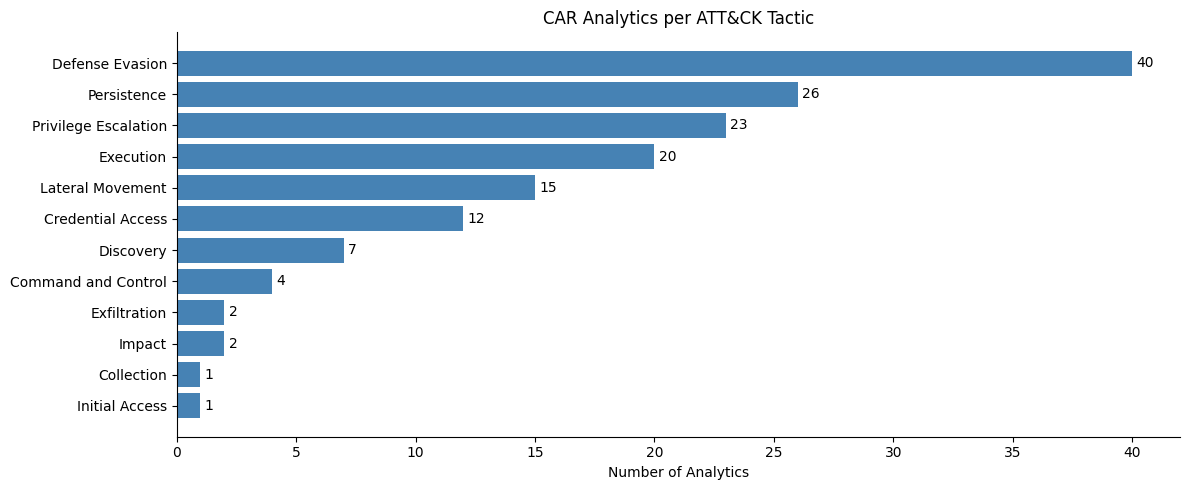


Note: analytics covering multiple tactics are counted once per tactic.


In [3]:
TACTIC_NAMES = {
    'TA0001': 'Initial Access',
    'TA0002': 'Execution',
    'TA0003': 'Persistence',
    'TA0004': 'Privilege Escalation',
    'TA0005': 'Defense Evasion',
    'TA0006': 'Credential Access',
    'TA0007': 'Discovery',
    'TA0008': 'Lateral Movement',
    'TA0009': 'Collection',
    'TA0010': 'Exfiltration',
    'TA0011': 'Command and Control',
    'TA0040': 'Impact',
    'TA0042': 'Resource Development',
    'TA0043': 'Reconnaissance',
}

tactic_counts = Counter(t for ts in df['tactics'] for t in ts)
tactic_df = pd.DataFrame(tactic_counts.most_common(), columns=['tactic_id', 'count'])
tactic_df['name'] = tactic_df['tactic_id'].map(TACTIC_NAMES).fillna(tactic_df['tactic_id'])

fig, ax = plt.subplots()
bars = ax.barh(tactic_df['name'], tactic_df['count'], color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Analytics')
ax.set_title('CAR Analytics per ATT&CK Tactic')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nNote: analytics covering multiple tactics are counted once per tactic.")

## 3. Platform Distribution

Which OS platforms do these analytics target?

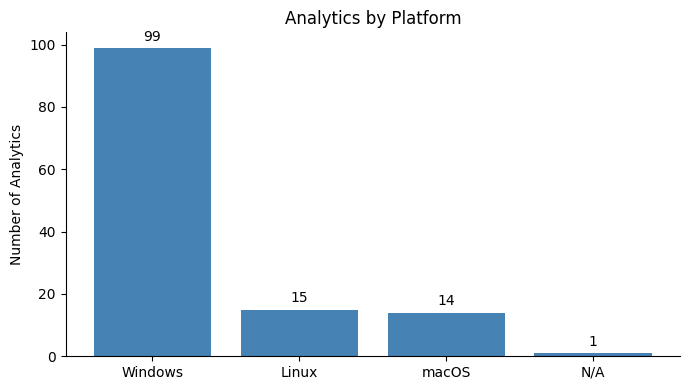

In [4]:
platform_counts = Counter(p for ps in df['platforms'] for p in ps)
platforms = pd.DataFrame(platform_counts.most_common(), columns=['platform', 'count'])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(platforms['platform'], platforms['count'], color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_ylabel('Number of Analytics')
ax.set_title('Analytics by Platform')
plt.tight_layout()
plt.show()

## 4. Analytic Type Distribution

CAR classifies analytics as:
- **TTP**: Detects a specific adversary behavior (Tactic, Technique, Procedure)
- **Situational Awareness**: Broad visibility, not necessarily malicious in isolation

**Why this matters:** TTP analytics are higher-signal for threat hunting. Situational Awareness analytics produce more noise.

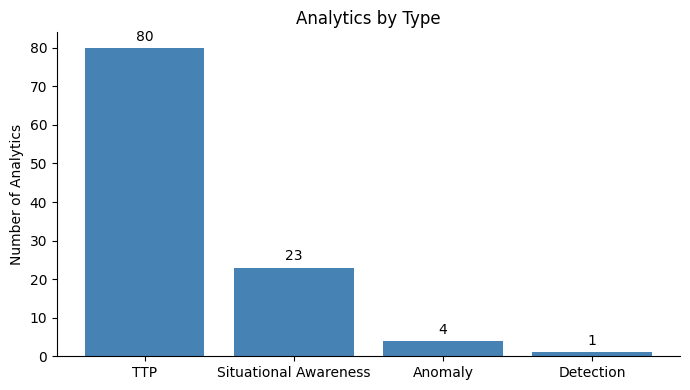

In [5]:
type_counts = Counter(t for ts in df['analytic_types'] for t in ts)
type_df = pd.DataFrame(type_counts.most_common(), columns=['type', 'count'])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(type_df['type'], type_df['count'], color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_ylabel('Number of Analytics')
ax.set_title('Analytics by Type')
plt.tight_layout()
plt.show()

## 5. Implementation Type Distribution

Analytics can have zero or more implementations. Types include Pseudocode, Splunk, EQL, Sigma, KQL, etc.

**Why this matters for query generation (Phase 4):** Only analytics with existing Splunk/EQL/KQL implementations give us a reference to compare our LLM-generated queries against.

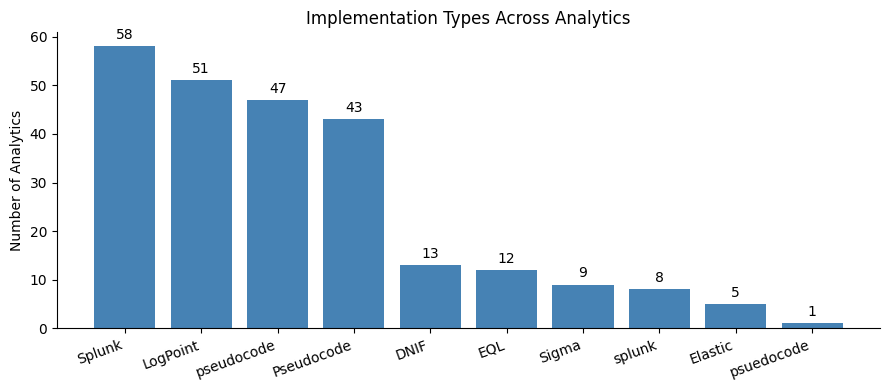


Analytics with NO implementations: 3
             id                            title
CAR-2013-01-002              Autorun Differences
CAR-2013-02-012 User Logged in to Multiple Hosts
CAR-2020-04-001             Shadow Copy Deletion


In [6]:
impl_counts = Counter(t for ts in df['impl_types'] for t in ts)
impl_df = pd.DataFrame(impl_counts.most_common(), columns=['type', 'count'])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(impl_df['type'], impl_df['count'], color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_ylabel('Number of Analytics')
ax.set_title('Implementation Types Across Analytics')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

no_impl = df[df['implementations'].apply(len) == 0]
print(f"\nAnalytics with NO implementations: {len(no_impl)}")
print(no_impl[['id','title']].to_string(index=False))

## 6. Coverage Level Distribution

Each technique mapping includes a coverage rating: Low / Moderate / High / Complete.
This tells you how well the analytic detects the technique — useful context for the LLM when generating hypotheses.

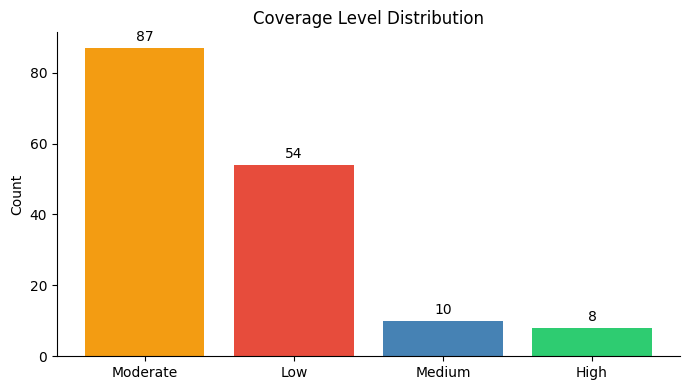

In [7]:
coverage_counts = Counter(c for cs in df['coverage_levels'] for c in cs)
cov_df = pd.DataFrame(coverage_counts.most_common(), columns=['level', 'count'])

colors = {'Low': '#e74c3c', 'Moderate': '#f39c12', 'High': '#2ecc71', 'Complete': '#27ae60'}
bar_colors = [colors.get(l, 'steelblue') for l in cov_df['level']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cov_df['level'], cov_df['count'], color=bar_colors)
ax.bar_label(bars, padding=3)
ax.set_ylabel('Count')
ax.set_title('Coverage Level Distribution')
plt.tight_layout()
plt.show()

## 7. CAR Data Model — Top Referenced Fields

The CAR data model uses `object/action/field` notation (e.g. `process/create/command_line`). These fields are what your SIEM queries will reference.

**Why this matters:** Field hallucination (failure mode #1) is when the LLM invents fields that don't exist in this schema. Knowing the most common real fields helps you spot hallucinations.

Total data model references across all analytics: 196
Unique references: 45



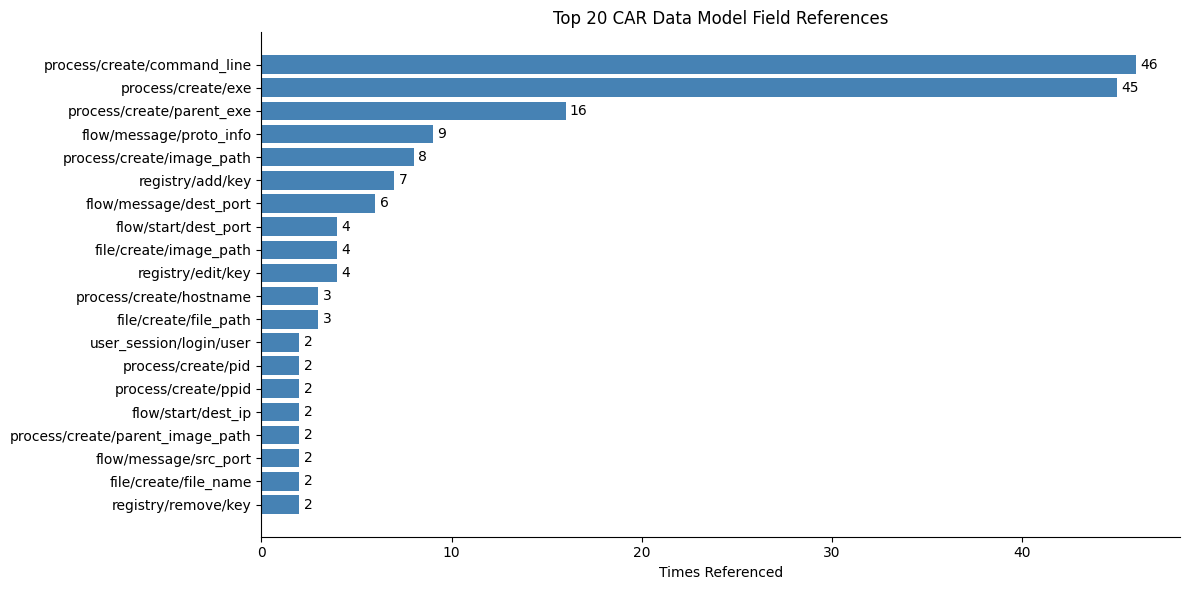


Top data model objects:
  process: 136
  flow: 28
  registry: 14
  file: 10
  user_session: 3
  thread: 3
  service: 2


In [8]:
all_refs = [r for refs in df['data_model_references'] for r in refs]
ref_counts = Counter(all_refs)

print(f"Total data model references across all analytics: {len(all_refs)}")
print(f"Unique references: {len(ref_counts)}\n")

ref_df = pd.DataFrame(ref_counts.most_common(20), columns=['reference', 'count'])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(ref_df['reference'], ref_df['count'], color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Times Referenced')
ax.set_title('Top 20 CAR Data Model Field References')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# also show the top object types
objects = Counter(r.split('/')[0] for r in all_refs)
print("\nTop data model objects:")
for obj, cnt in objects.most_common():
    print(f"  {obj}: {cnt}")

## 8. Analytics Without Data Model References

These analytics have no `data_model_references` — the LLM will have less grounding when generating field-specific queries for them.

In [9]:
no_refs = df[df['data_model_references'].apply(len) == 0]
print(f"Analytics with no data model references: {len(no_refs)} / {len(df)}")
print()
print(no_refs[['id', 'title', 'impl_types']].to_string(index=False))

Analytics with no data model references: 11 / 102

             id                                                  title                     impl_types
CAR-2013-01-002                                    Autorun Differences                             []
CAR-2013-02-012                       User Logged in to Multiple Hosts                             []
CAR-2013-10-001                         User Login Activity Monitoring     [Pseudocode, Splunk, DNIF]
CAR-2016-04-003 User Activity from Stopping Windows Defensive Services         [LogPoint, pseudocode]
CAR-2016-04-004                         Successful Local Account Login                   [pseudocode]
CAR-2016-04-005                                   Remote Desktop Logon  [LogPoint, Sigma, pseudocode]
CAR-2019-04-004                        Credential Dumping via Mimikatz             [LogPoint, splunk]
CAR-2019-07-001                         Access Permission Modification [Pseudocode, LogPoint, Splunk]
CAR-2020-04-001                

## 9. Most Covered Techniques

Which ATT&CK techniques have the most CAR analytics written for them?

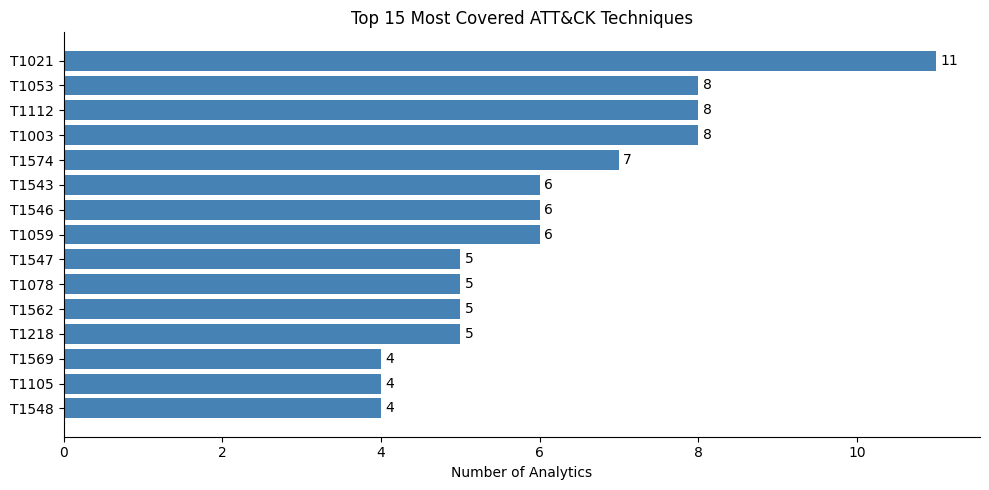

In [10]:
tech_counts = Counter(t for ts in df['techniques'] for t in ts)
tech_df = pd.DataFrame(tech_counts.most_common(15), columns=['technique', 'count'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(tech_df['technique'], tech_df['count'], color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Analytics')
ax.set_title('Top 15 Most Covered ATT&CK Techniques')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary — Key Takeaways

Run the cell below to print a summary of findings to carry forward into Phase 2.

In [11]:
has_splunk = df['impl_types'].apply(lambda ts: 'Splunk' in ts)
has_eql    = df['impl_types'].apply(lambda ts: 'EQL' in ts)
has_sigma  = df['impl_types'].apply(lambda ts: 'Sigma' in ts)

top_tactic = tactic_df.iloc[0]
bot_tactic = tactic_df.iloc[-1]

print("=" * 55)
print("PHASE 1 EDA SUMMARY")
print("=" * 55)
print(f"  Total analytics:              {len(df)}")
print(f"  Have at least 1 impl:         {df['implementations'].apply(len).gt(0).sum()}")
print(f"  Have Splunk query:            {has_splunk.sum()}")
print(f"  Have EQL query:               {has_eql.sum()}")
print(f"  Have Sigma rule:              {has_sigma.sum()}")
print(f"  No implementations at all:    {df['implementations'].apply(len).eq(0).sum()}")
print(f"  No data model references:     {len(no_refs)}")
print(f"  Unique ATT&CK techniques:     {len(set(t for ts in df['techniques'] for t in ts))}")
print(f"  Unique tactics:               {len(set(t for ts in df['tactics'] for t in ts))}")
print(f"  Most covered tactic:          {top_tactic['name']} ({top_tactic['count']} analytics)")
print(f"  Least covered tactic:         {bot_tactic['name']} ({bot_tactic['count']} analytics)")
print("=" * 55)

PHASE 1 EDA SUMMARY
  Total analytics:              102
  Have at least 1 impl:         99
  Have Splunk query:            58
  Have EQL query:               12
  Have Sigma rule:              9
  No implementations at all:    3
  No data model references:     11
  Unique ATT&CK techniques:     55
  Unique tactics:               12
  Most covered tactic:          Defense Evasion (40 analytics)
  Least covered tactic:         Initial Access (1 analytics)
